# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import tpvalidator.workspace as workspace
# import tpvalidator.analysis.snn as snn
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, cut_scan_to_df, compute_regaxis_specs

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from tpvalidator.viz.backtracker import BackTrackerPlotter
from tpvalidator.viz.display import TriggerPrimitivesEventViewer
from tpvalidator.viz.term import dataframe_to_rich_table
from typing import Literal


# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
datasets = dctl.load('data/vd/1x8x14/3sig', dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Workspace ar39 skipped

Workspace ar39_5e_00 skipped

Loading radbkg

Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

# Analysers

In [4]:
class RadBkgRateAnalyser:

    def __init__(self, rad_ws, em_ws):
        self._rad_ws = rad_ws
        self._em_ws = em_ws
        self.adc_peak_cuts = list(range(28,60,2))


    def do_total_rates(self):

        rad_ws = self._rad_ws
        em_ws = self._em_ws
        tpp = TrgPrimitivesPlotter(rad_ws)

        h_cs = tpp.make_cutsequence_hist('adc_peak', self.adc_peak_cuts)
        h_cs_tot = h_cs[:, sum, :]

        def col_crp_rate(r):
            if r > 1.5e5:
                col = 'red'
            elif r < 1e5:
                col = 'green'
            else:
                col = 'yellow'

            r_str = f'{r:.2f} Hz'
            if col:
                r_str = f'[{col}]{r_str}[/{col}]'
            return r_str
                



        h_rate_crp = h_cs_tot/tpp.simulated_time()/tpp.geo.num_crps

        rate_tot = cut_scan_to_df(h_rate_crp, 'readout_plane_id', 'adc_peak')
        rate_tot.rename(columns={
            f'readout_plane_id_{i}':f'rate_rop_{i}' for i in range(3)
        }, inplace=True)

        _fmts={
            f"rate_rop_{rop}": col_crp_rate for rop in range(3)
        }
        t_rate_tot = dataframe_to_rich_table(
            rate_tot,
            formatters=_fmts)
        t_rate_tot.title = "Rate per CRP"
        print(t_rate_tot)


        fig, axes = plt.subplots(1,3, figsize=(15,4))

        for rop_id in range(3):
            _ax=axes[rop_id]
            hep.histplot(h_rate_crp[rop_id,:], ax=_ax)

            _ax.set_yscale('log')
            _ax.set_title(f"RO Plane {rop_id}")
            _ax.axhline(1.5e5, c='darkorange')
            _ax.axhline(1e5, c='red')

        fig.tight_layout()

    

    def make_cut_scan(self):

        rad_ws = self._rad_ws
        tpp = TrgPrimitivesPlotter(rad_ws)

        h_cs = tpp.make_cutsequence_hist('adc_peak', self.adc_peak_cuts)
        h_cs_bkg = h_cs[:, 1j, :]
        h_cs_noi = h_cs[:, 0j, :]
        h_cs_tot = h_cs[:, sum, :]
        h_rate_crp = h_cs_tot/tpp.simulated_time()/tpp.geo.num_crps


        h_rate_bkg_crp = h_cs_bkg/tpp.simulated_time()/tpp.geo.num_crps
        h_rate_noi_crp = h_cs_noi/tpp.simulated_time()/tpp.geo.num_crps


        cut_scan_bkg = cut_scan_to_df(h_rate_bkg_crp, 'readout_plane_id', 'adc_peak')
        cut_scan_noi = cut_scan_to_df(h_rate_noi_crp, 'readout_plane_id', 'adc_peak')


        cut_scan_bkg.rename(columns={
            f'readout_plane_id_{i}':f'rate_rop_{i}' for i in range(3)
        }, inplace=True)
        cut_scan_noi.rename(columns={
            f'readout_plane_id_{i}':f'rate_rop_{i}' for i in range(3)
        }, inplace=True)

        cut_scan = pd.merge(cut_scan_bkg, cut_scan_noi, on="adc_peak_min", suffixes=('_bkg', '_noi'))

        return cut_scan

    def do_purity_tables(self):

        _fmts={
            f"rate_rop_{rop}_{ds}": '{:0.2f} Hz' for rop in range(3) for ds in ('bkg', 'noi')
        }

        _fmts.update({
            'ratio': '{:.2f}'
        })

        cut_scan=self.make_cut_scan()

        for i in range(3):
            cut_scan_rop = cut_scan[["adc_peak_min", f'rate_rop_{i}_bkg', f'rate_rop_{i}_noi']]
            cut_scan_rop['ratio'] = cut_scan[f'rate_rop_{i}_noi']/cut_scan[f'rate_rop_{i}_bkg']
            print(dataframe_to_rich_table(cut_scan_rop, formatters=_fmts, show_index=True, title=f'Background vs Noise rates (ROP {i})'))

    def do_corrected_purity_tables(self):

        _fmts={
            f"rate_rop_{rop}_{ds}": '{:0.2f} Hz' for rop in range(3) for ds in ('bkg', 'noi')
        }

        _fmts.update({
            'ratio': '{:.2f}'
        })
        
        cut_scan=self.make_cut_scan()

        cut_scan[f'rate_rop_0_bkg'] = cut_scan[f'rate_rop_0_bkg']+cut_scan[f'rate_rop_0_noi']-cut_scan[f'rate_rop_2_noi']
        cut_scan[f'rate_rop_1_bkg'] = cut_scan[f'rate_rop_1_bkg']+cut_scan[f'rate_rop_1_noi']-cut_scan[f'rate_rop_2_noi']
        cut_scan[f'rate_rop_0_noi'] = cut_scan[f'rate_rop_2_noi']
        cut_scan[f'rate_rop_1_noi'] = cut_scan[f'rate_rop_2_noi']


        for i in range(3):
            cut_scan_rop = cut_scan[["adc_peak_min", f'rate_rop_{i}_bkg', f'rate_rop_{i}_noi']]
            cut_scan_rop['ratio'] = cut_scan[f'rate_rop_{i}_noi']/cut_scan[f'rate_rop_{i}_bkg']
            print(dataframe_to_rich_table(cut_scan_rop, formatters=_fmts, show_index=True, title=f'Background vs Noise rates (ROP {i})'))

# Trigger Primitive Rates vs `adc_peak`
---

Calculate the trigger primitives rate as a function of the `adc_peak`  TP threshold.

Highlight regions below 100 kHz (green), between 100 kHz and 150 kHz (yellow), and above 150 kHz (red)

                            Rate per CRP                             
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_0    ┃ rate_rop_1    ┃ rate_rop_2    ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0  │ 28.0         │ 1848587.39 Hz │ 1836888.24 Hz │ 1958559.66 Hz │
│ 1  │ 30.0         │ 1000059.66 Hz │ 981062.18 Hz  │ 1014973.11 Hz │
│ 2  │ 32.0         │ 552958.82 Hz  │ 529071.43 Hz  │ 544288.24 Hz  │
│ 3  │ 34.0         │ 322497.48 Hz  │ 296134.45 Hz  │ 319451.26 Hz  │
│ 4  │ 36.0         │ 206827.73 Hz  │ 179746.22 Hz  │ 215671.43 Hz  │
│ 5  │ 38.0         │ 149448.74 Hz  │ 122152.94 Hz  │ 166618.49 Hz  │
│ 6  │ 40.0         │ 120132.77 Hz  │ 93168.07 Hz   │ 141922.69 Hz  │
│ 7  │ 42.0         │ 104367.23 Hz  │ 77392.44 Hz   │ 128520.17 Hz  │
│ 8  │ 44.0         │ 94331.93 Hz   │ 67691.60 Hz   │ 119898.32 Hz  │
│ 9  │ 46.0         │ 87382.35 Hz   │ 61283.19 Hz   │ 113202.52 Hz  │
│ 10 │ 48.0         │ 81863.03 Hz   │ 56449.58 Hz   │ 107460.50 Hz  │
│ 11 │ 50.0         │ 77153.78 Hz   │ 52306.72 Hz   │ 102178.15 Hz  │
│ 12 │ 52.0         │ 72857.14 Hz   │ 48834.45 Hz   │ 97544.54 Hz   │
│ 13 │ 54.0         │ 68991.60 Hz   │ 45636.97 Hz   │ 93130.25 Hz   │
│ 14 │ 56.0         │ 65455.46 Hz   │ 42762.18 Hz   │ 89043.70 Hz   │
│ 15 │ 58.0         │ 62156.30 Hz   │ 40160.50 Hz   │ 85232.77 Hz   │
└────┴──────────────┴───────────────┴───────────────┴───────────────┘

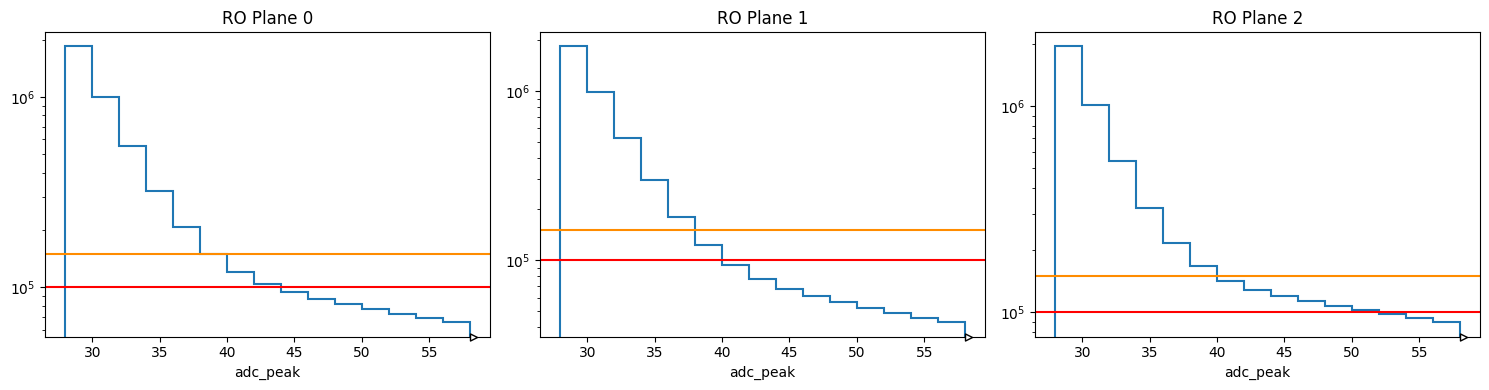

In [5]:
ana = RadBkgRateAnalyser(rad_ws=rad_ws, em_ws=em_ws)
ana.do_total_rates()

### Observations
- The TP rates thrends differ significantly between the collection plane and the induction planes.
- The induction plane rates drop faster than the collection rate.
- The reference rate of 100 kHz is reached only at `adc_peak==50` on the collection plane, whereas it is reach at `adc_peak==44 and 40` for the two induction planes
  
### Conclusions
- For MC prodcution, the threshold selection target is ~150 kHz background rate per plane.
- This translates to 
  - I0: 38
  - I2: 38
  - C: 40 (or 38 for simplicity)


# Impact of increasing TP threshold on e- backtracking efficiency 
---

Question: what fraction of e- signal is lost at the increase of the TP threshold?
- Sample: e-minus, 100 events
- Energy: 1-100 MeV
The e- sample is choosen since e- are the reference interaction in low-E regions

Steps:
- Plot KE distribution to confirm sufficient presence of low energy events
- Calculate the relative loss of backtracking efficiency as a function of adc_peak cut
  - Use relative loss since plane efficiencis are different
  - Plot the evolution of relative efficiency loss vs threshold
  - Confirm that losses in the are negligible for e- event

---

Text(0, 0.5, 'Counts')

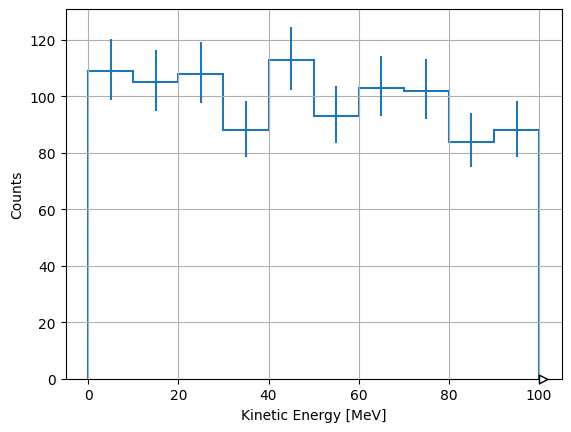

In [6]:
h = hist.Hist(hist.axis.Regular(10, 0, 100, underflow=True, overflow=True, name="ke", label='Kinetic Energy [MeV]'))

h.fill((em_ws.mctruths.kinetic_energy*1000))

fig, ax = plt.subplots(1,1)
hep.histplot(h, histtype='step', ax=ax)

ax.grid()
ax.set_ylabel('Counts')

# (em_ws.mctruths.kinetic_energy*1000).hist(bins=25)


In [7]:
btp = BackTrackerPlotter(em_ws)
evw = TriggerPrimitivesEventViewer(em_ws)

### Completeness (Backtracking efficiency) across planes for single $e^{-}$ events [1-100 MeV]

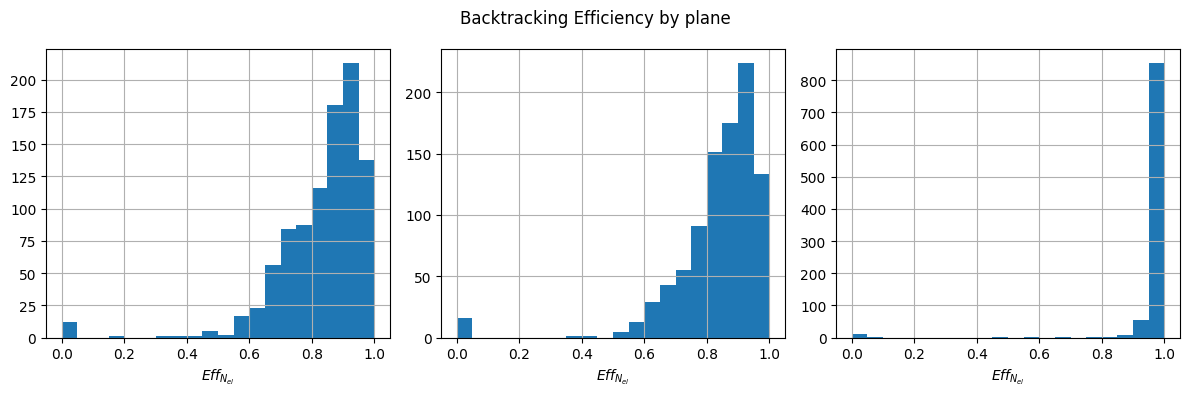

In [8]:
fig = btp.draw_nel_eff_by_plane(bins=20)

**Notable features**: 
- A small fraction of events are effectively not captured by TPs (eff < 0.1>)
- They are present on all planes
- As usual, induction planes are less effective in capturing the drift electron information

### Impact of incremental `adc_peak` cuts on completeness

,0
nel_eff_rop0,0.821913
nel_eff_rop1,0.822439
nel_eff_rop2,0.900194


     Single e- relative efficiency (n_el) vs threhshold      
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ adc_peak_min ┃ nel_eff_rop0 ┃ nel_eff_rop1 ┃ nel_eff_rop2 ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 26.0         │ 1.00         │ 1.00         │ 1.00         │
│ 28.0         │ 1.00         │ 1.00         │ 1.00         │
│ 30.0         │ 0.99         │ 1.00         │ 1.00         │
│ 32.0         │ 0.99         │ 1.00         │ 1.00         │
│ 34.0         │ 0.99         │ 1.00         │ 1.00         │
│ 36.0         │ 0.99         │ 1.00         │ 0.99         │
│ 38.0         │ 0.99         │ 1.00         │ 0.99         │
│ 40.0         │ 0.99         │ 0.99         │ 0.99         │
│ 42.0         │ 0.98         │ 0.99         │ 0.99         │
│ 44.0         │ 0.98         │ 0.99         │ 0.99         │
│ 46.0         │ 0.98         │ 0.99         │ 0.99         │
│ 48.0         │ 0.98         │ 0.98         │ 0.99         │
│ 50.0         │ 0.97         │ 0.98         │ 0.98         │
│ 52.0         │ 0.97         │ 0.98         │ 0.98         │
│ 54.0         │ 0.97         │ 0.98         │ 0.98         │
│ 56.0         │ 0.97         │ 0.97         │ 0.98         │
│ 58.0         │ 0.96         │ 0.97         │ 0.97         │
│ 60.0         │ 0.96         │ 0.97         │ 0.97         │
└──────────────┴──────────────┴──────────────┴──────────────┘

Text(0.5, 1.0, 'Single $e^{-}$ (1-20 MeV) relative efficiency ($N^{el}$) vs threhshold')

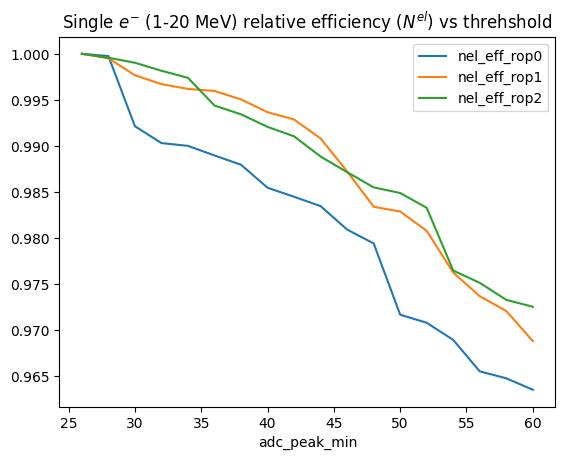

In [9]:
ke_cut = "kinetic_energy < 20/1000"
# ke_cut = "kinetic_energy > 50/1000"

adc_cutsequence = np.arange(26,61,2)

eff_base = btp.compute_nel_eff_by_plane()
ke = em_ws.mctruths[['event_uid', 'kinetic_energy']]
eff_base = eff_base.merge(ke, on='event_uid')
eff_base.query(ke_cut, inplace=True)

# quality cut: if collection efficiency is 0, the event was not visible
# eff_base.query("nel_eff_rop2 > 0", inplace=True)

eff_base_m = eff_base.mean()
display(pd.DataFrame(eff_base_m[['nel_eff_rop0', 'nel_eff_rop1', 'nel_eff_rop2']]))


rows = []


for adc_peak_min in adc_cutsequence:
    eff_cut = btp.compute_nel_eff_by_plane(f"adc_peak > {adc_peak_min}")
    eff_cut = eff_cut.merge(ke, on='event_uid')
    eff_cut.query(ke_cut, inplace=True)

    # quality cut: if collection efficiency is 0, the event was not visible
    # eff_cut.query("nel_eff_rop2 > 0", inplace=True)

    m = (eff_cut.mean()/eff_base_m)
    m= m.drop(['event_uid', 'kinetic_energy'])
    
    m['adc_peak_min'] = adc_peak_min

    rows.append(m)

x = pd.DataFrame(rows)
x.set_index('adc_peak_min', inplace=True)

_fmts={
    f"nel_eff_rop{rop}":'{:.2f}' for rop in range(3)
}

t = dataframe_to_rich_table(x, formatters=_fmts, show_index=True, index_name='adc_peak_min')
t.title = 'Single e- relative efficiency (n_el) vs threhshold'
print(t)

fig, ax = plt.subplots(1,1)

x.plot(ax=ax)
ax.set_title('Single $e^{-}$ (1-20 MeV) relative efficiency ($N^{el}$) vs threhshold')




### Observations

The increase in `adc_peak` threshold has a negligible impact on the ability to single $e^{-}$ completeness.

# What is the Noise/Backgrounds TP composition vs threshold?

- What is the fraction of backgrounds TPs vs noise?
- Is it compatible with expectations?
- If not:
  - Is the estimate reliable?
  - What is the cause?

In [10]:
bkg_ana = RadBkgRateAnalyser(rad_ws, em_ws)

In [11]:
bkg_ana.do_purity_tables()

               Background vs Noise rates (ROP 0)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_0_bkg ┃ rate_rop_0_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 145874.79 Hz   │ 1702712.61 Hz  │ 11.67 │
│ 1  │ 30.0         │ 133811.76 Hz   │ 866247.90 Hz   │ 6.47  │
│ 2  │ 32.0         │ 123645.38 Hz   │ 429313.45 Hz   │ 3.47  │
│ 3  │ 34.0         │ 114697.48 Hz   │ 207800.00 Hz   │ 1.81  │
│ 4  │ 36.0         │ 106810.92 Hz   │ 100016.81 Hz   │ 0.94  │
│ 5  │ 38.0         │ 99888.24 Hz    │ 49560.50 Hz    │ 0.50  │
│ 6  │ 40.0         │ 93440.34 Hz    │ 26692.44 Hz    │ 0.29  │
│ 7  │ 42.0         │ 87769.75 Hz    │ 16597.48 Hz    │ 0.19  │
│ 8  │ 44.0         │ 82499.16 Hz    │ 11832.77 Hz    │ 0.14  │
│ 9  │ 46.0         │ 77754.62 Hz    │ 9627.73 Hz     │ 0.12  │
│ 10 │ 48.0         │ 73514.29 Hz    │ 8348.74 Hz     │ 0.11  │
│ 11 │ 50.0         │ 69638.66 Hz    │ 7515.13 Hz     │ 0.11  │
│ 12 │ 52.0         │ 66022.69 Hz    │ 6834.45 Hz     │ 0.10  │
│ 13 │ 54.0         │ 62707.56 Hz    │ 6284.03 Hz     │ 0.10  │
│ 14 │ 56.0         │ 59684.03 Hz    │ 5771.43 Hz     │ 0.10  │
│ 15 │ 58.0         │ 56843.70 Hz    │ 5312.61 Hz     │ 0.09  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

               Background vs Noise rates (ROP 1)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_1_bkg ┃ rate_rop_1_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 114778.15 Hz   │ 1722110.08 Hz  │ 15.00 │
│ 1  │ 30.0         │ 101289.08 Hz   │ 879773.11 Hz   │ 8.69  │
│ 2  │ 32.0         │ 90970.59 Hz    │ 438100.84 Hz   │ 4.82  │
│ 3  │ 34.0         │ 82732.77 Hz    │ 213401.68 Hz   │ 2.58  │
│ 4  │ 36.0         │ 75874.79 Hz    │ 103871.43 Hz   │ 1.37  │
│ 5  │ 38.0         │ 69789.08 Hz    │ 52363.87 Hz    │ 0.75  │
│ 6  │ 40.0         │ 64536.13 Hz    │ 28631.93 Hz    │ 0.44  │
│ 7  │ 42.0         │ 59916.81 Hz    │ 17475.63 Hz    │ 0.29  │
│ 8  │ 44.0         │ 55644.54 Hz    │ 12047.06 Hz    │ 0.22  │
│ 9  │ 46.0         │ 51874.79 Hz    │ 9408.40 Hz     │ 0.18  │
│ 10 │ 48.0         │ 48515.13 Hz    │ 7934.45 Hz     │ 0.16  │
│ 11 │ 50.0         │ 45357.14 Hz    │ 6949.58 Hz     │ 0.15  │
│ 12 │ 52.0         │ 42633.61 Hz    │ 6200.84 Hz     │ 0.15  │
│ 13 │ 54.0         │ 40078.99 Hz    │ 5557.98 Hz     │ 0.14  │
│ 14 │ 56.0         │ 37760.50 Hz    │ 5001.68 Hz     │ 0.13  │
│ 15 │ 58.0         │ 35647.90 Hz    │ 4512.61 Hz     │ 0.13  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

               Background vs Noise rates (ROP 2)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_2_bkg ┃ rate_rop_2_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 190503.36 Hz   │ 1768056.30 Hz  │ 9.28  │
│ 1  │ 30.0         │ 176531.93 Hz   │ 838441.18 Hz   │ 4.75  │
│ 2  │ 32.0         │ 164917.65 Hz   │ 379370.59 Hz   │ 2.30  │
│ 3  │ 34.0         │ 154794.12 Hz   │ 164657.14 Hz   │ 1.06  │
│ 4  │ 36.0         │ 145791.60 Hz   │ 69879.83 Hz    │ 0.48  │
│ 5  │ 38.0         │ 137599.16 Hz   │ 29019.33 Hz    │ 0.21  │
│ 6  │ 40.0         │ 130067.23 Hz   │ 11855.46 Hz    │ 0.09  │
│ 7  │ 42.0         │ 123271.43 Hz   │ 5248.74 Hz     │ 0.04  │
│ 8  │ 44.0         │ 116997.48 Hz   │ 2900.84 Hz     │ 0.02  │
│ 9  │ 46.0         │ 111171.43 Hz   │ 2031.09 Hz     │ 0.02  │
│ 10 │ 48.0         │ 105896.64 Hz   │ 1563.87 Hz     │ 0.01  │
│ 11 │ 50.0         │ 100897.48 Hz   │ 1280.67 Hz     │ 0.01  │
│ 12 │ 52.0         │ 96421.01 Hz    │ 1123.53 Hz     │ 0.01  │
│ 13 │ 54.0         │ 92153.78 Hz    │ 976.47 Hz      │ 0.01  │
│ 14 │ 56.0         │ 88202.52 Hz    │ 841.18 Hz      │ 0.01  │
│ 15 │ 58.0         │ 84487.39 Hz    │ 745.38 Hz      │ 0.01  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

### Observations

- The bkg/noise ratio (purity) rapidly falls to zero as expected only for the collection plane
- The purity settles to 10-12% for induction planes
- Based on previous experience, this is likey to be related to TPs being erroneously flagged as noise on the induction planes

### Trigger Primitive distribution inspection

The separation of TPs in noise and signal depends on backtracking and the presence of `SimChannels` in detsim products.
Is is know that in radioactive background samples, high-energy noise TPs are found, compatible with background deposits  even if none is found


## TP backgrounds/noise distributions

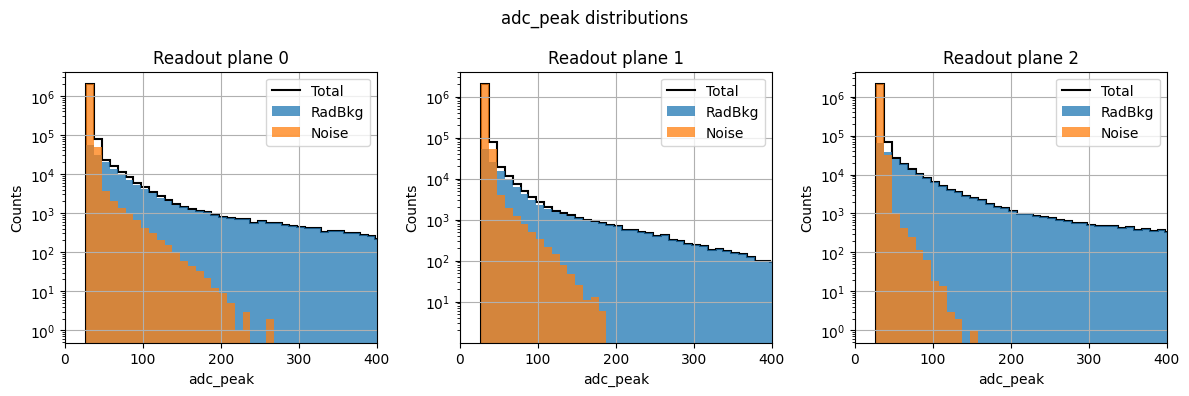

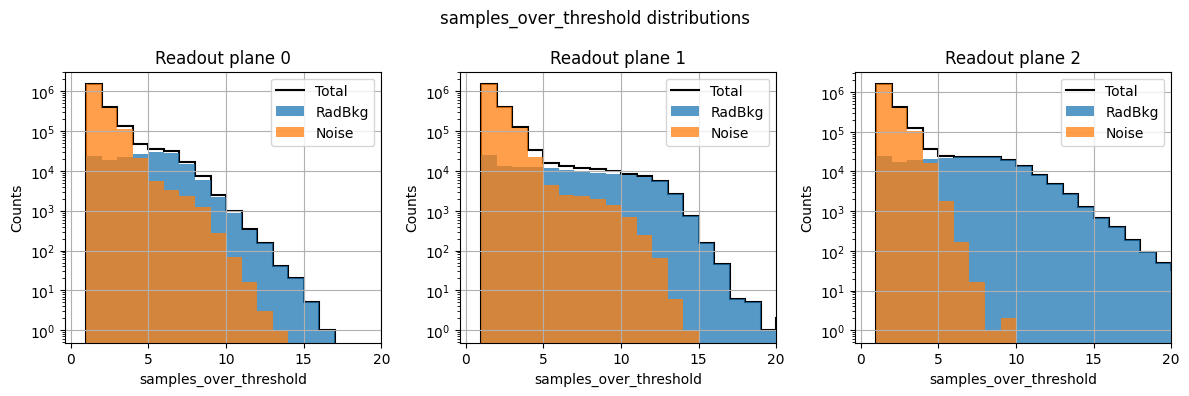

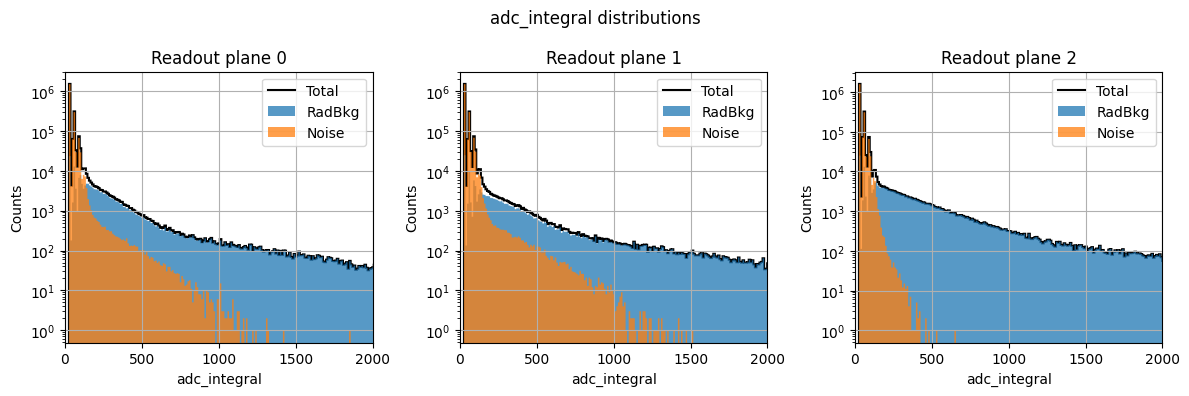

In [12]:

tpp = TrgPrimitivesPlotter(rad_ws)

vars = {
    'adc_peak': {'bin_size': 10, 'xlim': (0, 400)},
    'samples_over_threshold': {'bin_size': 1, 'xlim': (None, 20)},
    'adc_integral': {'bin_size': 10, 'xlim': (0, 2000)},
}
for v, cfg in vars.items():
    h = tpp.make_var_reghist(v, cfg['bin_size'])

    fig, axes = plt.subplots(1,3, figsize=(12,4))

    for rop_id in range(3):
        ax=axes[rop_id]

        hep.histplot(h[rop_id,sum,:], ax=ax, yerr=False, color='black', label='Total')
        hep.histplot(h[rop_id,1,:], ax=ax, yerr=False, histtype='fill', label='RadBkg', alpha=0.75)
        hep.histplot(h[rop_id,0,:], ax=ax, yerr=False, histtype='fill', label='Noise', alpha=0.75)
        ax.set_yscale('log')
        ax.set_xlim(*cfg['xlim'])
        ax.grid()
        ax.legend()
        ax.set_ylabel('Counts')
        
        ax.set_title(f"Readout plane {rop_id}")
    fig.suptitle(f"{v} distributions")

    fig.tight_layout()

### Observations


- All distributions of TP variables flagged as 'noise' (not backtracked to a deposit) show a tail at high values
- The tail is more pronounced in induction planes
- The noise profile used in WireCell, the same across planes [_to my understanding_]
  - This supported by raw adc distributions from electron gun samples
- Inspection of noise TPs with high `adc_peak`/`samples_over_threshold`/`adc_integral` valies shows no presence of `simides` on the same channel
- The noise tail shape matches the background shape for all varialbles
- This strongly suggests that the origin of the tail is a mistagging/detsim issue

## TP e- sample TP signal/noise distributions

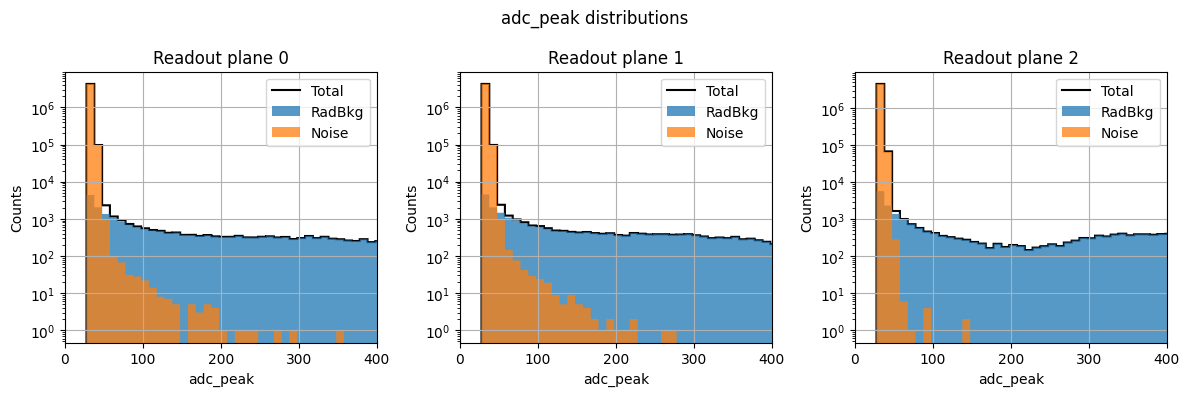

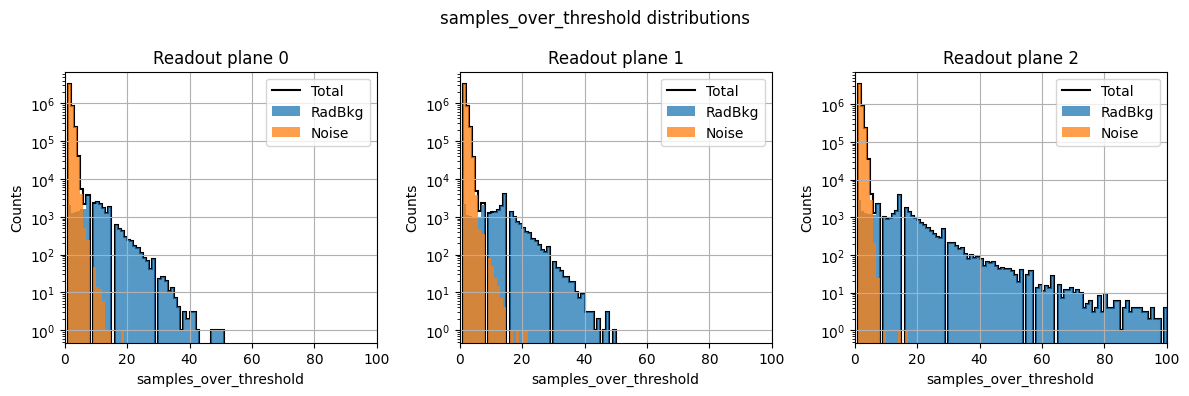

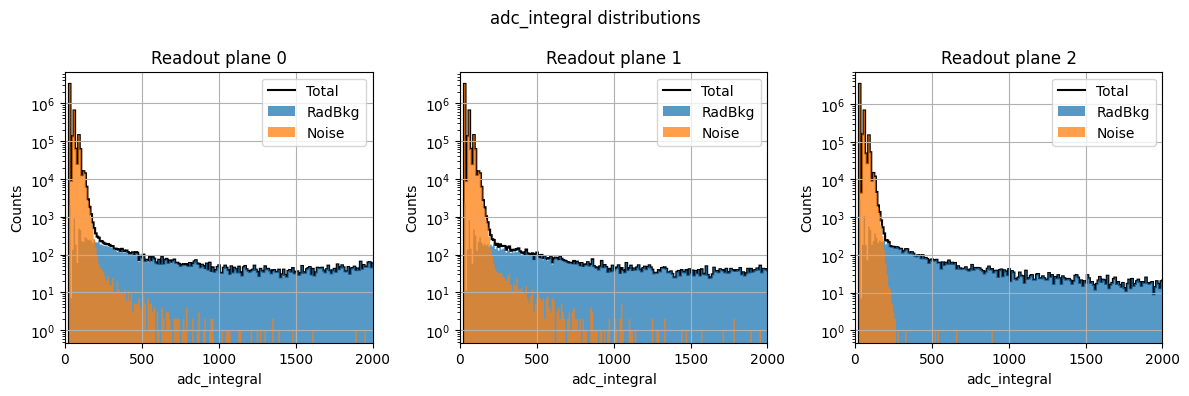

In [13]:
tpp = TrgPrimitivesPlotter(em_ws)

vars = {
    'adc_peak': {'bin_size': 10, 'xlim': (0, 400)},
    'samples_over_threshold': {'bin_size': 1, 'xlim': (0, 100)},
    'adc_integral': {'bin_size': 10, 'xlim': (0, 2000)},
}
for v, cfg in vars.items():
    h = tpp.make_var_reghist(v, cfg['bin_size'])

    fig, axes = plt.subplots(1,3, figsize=(12,4))

    for rop_id in range(3):
        ax=axes[rop_id]

        hep.histplot(h[rop_id,sum,:], ax=ax, yerr=False, color='black', label='Total')
        hep.histplot(h[rop_id,1,:], ax=ax, yerr=False, histtype='fill', label='RadBkg', alpha=0.75)
        hep.histplot(h[rop_id,0,:], ax=ax, yerr=False, histtype='fill', label='Noise', alpha=0.75)
        ax.set_yscale('log')
        ax.set_xlim(*cfg['xlim'])
        ax.grid()
        ax.legend()
        ax.set_ylabel('Counts')
        
        ax.set_title(f"Readout plane {rop_id}")
    fig.suptitle(f"{v} distributions")

    fig.tight_layout()

### Observation

The noise TP distributions from the e- sample show similar features, although less prominent.
- the e- sample was produced in hydra mode, only the noise in TPCs where signal is present are simulated.


## Corrected purity tables

These are purity tables where the noise TP count is taken from the collection plane for all planes.

This is motivated by the expectation for the noise distribution to be the same across planes.
- To be confirmed

In [14]:
ana.do_corrected_purity_tables()

               Background vs Noise rates (ROP 0)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_0_bkg ┃ rate_rop_0_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 80531.09 Hz    │ 1768056.30 Hz  │ 21.95 │
│ 1  │ 30.0         │ 161618.49 Hz   │ 838441.18 Hz   │ 5.19  │
│ 2  │ 32.0         │ 173588.24 Hz   │ 379370.59 Hz   │ 2.19  │
│ 3  │ 34.0         │ 157840.34 Hz   │ 164657.14 Hz   │ 1.04  │
│ 4  │ 36.0         │ 136947.90 Hz   │ 69879.83 Hz    │ 0.51  │
│ 5  │ 38.0         │ 120429.41 Hz   │ 29019.33 Hz    │ 0.24  │
│ 6  │ 40.0         │ 108277.31 Hz   │ 11855.46 Hz    │ 0.11  │
│ 7  │ 42.0         │ 99118.49 Hz    │ 5248.74 Hz     │ 0.05  │
│ 8  │ 44.0         │ 91431.09 Hz    │ 2900.84 Hz     │ 0.03  │
│ 9  │ 46.0         │ 85351.26 Hz    │ 2031.09 Hz     │ 0.02  │
│ 10 │ 48.0         │ 80299.16 Hz    │ 1563.87 Hz     │ 0.02  │
│ 11 │ 50.0         │ 75873.11 Hz    │ 1280.67 Hz     │ 0.02  │
│ 12 │ 52.0         │ 71733.61 Hz    │ 1123.53 Hz     │ 0.02  │
│ 13 │ 54.0         │ 68015.13 Hz    │ 976.47 Hz      │ 0.01  │
│ 14 │ 56.0         │ 64614.29 Hz    │ 841.18 Hz      │ 0.01  │
│ 15 │ 58.0         │ 61410.92 Hz    │ 745.38 Hz      │ 0.01  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

               Background vs Noise rates (ROP 1)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_1_bkg ┃ rate_rop_1_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 68831.93 Hz    │ 1768056.30 Hz  │ 25.69 │
│ 1  │ 30.0         │ 142621.01 Hz   │ 838441.18 Hz   │ 5.88  │
│ 2  │ 32.0         │ 149700.84 Hz   │ 379370.59 Hz   │ 2.53  │
│ 3  │ 34.0         │ 131477.31 Hz   │ 164657.14 Hz   │ 1.25  │
│ 4  │ 36.0         │ 109866.39 Hz   │ 69879.83 Hz    │ 0.64  │
│ 5  │ 38.0         │ 93133.61 Hz    │ 29019.33 Hz    │ 0.31  │
│ 6  │ 40.0         │ 81312.61 Hz    │ 11855.46 Hz    │ 0.15  │
│ 7  │ 42.0         │ 72143.70 Hz    │ 5248.74 Hz     │ 0.07  │
│ 8  │ 44.0         │ 64790.76 Hz    │ 2900.84 Hz     │ 0.04  │
│ 9  │ 46.0         │ 59252.10 Hz    │ 2031.09 Hz     │ 0.03  │
│ 10 │ 48.0         │ 54885.71 Hz    │ 1563.87 Hz     │ 0.03  │
│ 11 │ 50.0         │ 51026.05 Hz    │ 1280.67 Hz     │ 0.03  │
│ 12 │ 52.0         │ 47710.92 Hz    │ 1123.53 Hz     │ 0.02  │
│ 13 │ 54.0         │ 44660.50 Hz    │ 976.47 Hz      │ 0.02  │
│ 14 │ 56.0         │ 41921.01 Hz    │ 841.18 Hz      │ 0.02  │
│ 15 │ 58.0         │ 39415.13 Hz    │ 745.38 Hz      │ 0.02  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

               Background vs Noise rates (ROP 2)               
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    ┃ adc_peak_min ┃ rate_rop_2_bkg ┃ rate_rop_2_noi ┃ ratio ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 0  │ 28.0         │ 190503.36 Hz   │ 1768056.30 Hz  │ 9.28  │
│ 1  │ 30.0         │ 176531.93 Hz   │ 838441.18 Hz   │ 4.75  │
│ 2  │ 32.0         │ 164917.65 Hz   │ 379370.59 Hz   │ 2.30  │
│ 3  │ 34.0         │ 154794.12 Hz   │ 164657.14 Hz   │ 1.06  │
│ 4  │ 36.0         │ 145791.60 Hz   │ 69879.83 Hz    │ 0.48  │
│ 5  │ 38.0         │ 137599.16 Hz   │ 29019.33 Hz    │ 0.21  │
│ 6  │ 40.0         │ 130067.23 Hz   │ 11855.46 Hz    │ 0.09  │
│ 7  │ 42.0         │ 123271.43 Hz   │ 5248.74 Hz     │ 0.04  │
│ 8  │ 44.0         │ 116997.48 Hz   │ 2900.84 Hz     │ 0.02  │
│ 9  │ 46.0         │ 111171.43 Hz   │ 2031.09 Hz     │ 0.02  │
│ 10 │ 48.0         │ 105896.64 Hz   │ 1563.87 Hz     │ 0.01  │
│ 11 │ 50.0         │ 100897.48 Hz   │ 1280.67 Hz     │ 0.01  │
│ 12 │ 52.0         │ 96421.01 Hz    │ 1123.53 Hz     │ 0.01  │
│ 13 │ 54.0         │ 92153.78 Hz    │ 976.47 Hz      │ 0.01  │
│ 14 │ 56.0         │ 88202.52 Hz    │ 841.18 Hz      │ 0.01  │
│ 15 │ 58.0         │ 84487.39 Hz    │ 745.38 Hz      │ 0.01  │
└────┴──────────────┴────────────────┴────────────────┴───────┘

### Observations

Correcting the purity with collection TP rates brings the numbers closer to expectations (is this actually correct?)

**Note**: At low thresholds (28-30), the correction introduces features in the background rates. Rates increase, before starting to decrease. This is due to normalisation issues.

At `adc_peak >= 38`, the fraction of noise TPs is 20-30%

# Conclusions



# Old Code

In [58]:
tpp.make_generator_rates_table('adc_peak > 38 & readout_plane_id ==2')

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ counts     ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ 3  │ CavernwallGammasAtLAr1x8x14             │ 1684117.65 │
│ 1  │ Ar39GenInLAr                            │ 1623129.41 │
│ 0  │ WireCellToolkit                         │ 519929.41  │
│ 8  │ Kr85GenInLAr                            │ 217882.35  │
│ 25 │ foamGammasAtLAr1x8x14                   │ 67952.94   │
│ 22 │ Th232ChainGenInCathode                  │ 50941.18   │
│ 21 │ Th232ChainGenInAnode                    │ 46776.47   │
│ 23 │ U238ChainGenInAnode                     │ 19364.71   │
│ 24 │ U238ChainGenInCathode                   │ 12094.12   │
│ 11 │ Rn222ChainBi214GenInLAr                 │ 5458.82    │
│ 13 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 3741.18    │
│ 9  │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 3458.82    │
│ 4  │ K40GenInAnode                           │ 2847.06    │
│ 5  │ K40GenInCathode                         │ 2376.47    │
│ 10 │ Rn220ChainPb212GenInLAr                 │ 1929.41    │
│ 18 │ Rn222ChainPb214GenInLAr                 │ 1741.18    │
│ 12 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 1411.76    │
│ 7  │ K42From42ArGenInUpperMesh1x8x14         │ 776.47     │
│ 15 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 705.88     │
│ 2  │ Ar42GenInLAr                            │ 235.29     │
│ 19 │ Rn222ChainPo218GenInLAr                 │ 211.76     │
│ 20 │ Rn222ChainRn222GenInLAr                 │ 141.18     │
│ 6  │ K42From42ArGenInLAr                     │ 47.06      │
│ 14 │ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 0.00       │
│ 16 │ Rn222ChainFromPo218GenInUpperMesh1x8x14 │ 0.00       │
│ 17 │ Rn222ChainPb210GenInLAr                 │ 0.00       │
└────┴─────────────────────────────────────────┴────────────┘

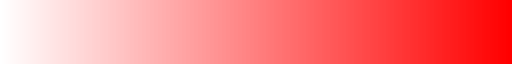

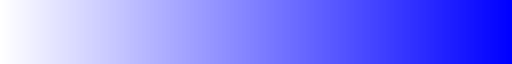

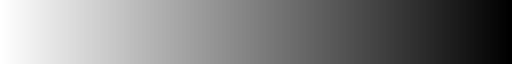

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cmap_trans_red = LinearSegmentedColormap.from_list(
    'trans_red',
    [(1, 0, 0, 0), (1, 0, 0, 1)]   # transparent red → solid red
)

cmap_trans_blue = LinearSegmentedColormap.from_list(
    'trans_red',
    [(0, 0, 1, 0), (0, 0, 1, 1)]   # transparent red → solid red
)

cmap_trans_black = LinearSegmentedColormap.from_list(
    'trans_red',
    [(0, 0, 0, 0), (0, 0, 0, 1)]   # transparent red → solid red
)

display(cmap_trans_red)
display(cmap_trans_blue)
display(cmap_trans_black)

IndexError: Wrong number of indices for histogram

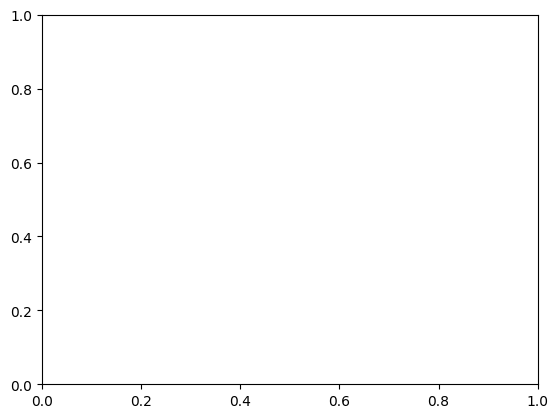

In [48]:
from matplotlib.colors import LogNorm

fix, axes = plt.subplots(1,1)

rop_id = 1
hep.hist2dplot(h[rop_id,1,:400j,:16j], cmap=cmap_trans_black, ax=axes, norm=LogNorm())
hep.hist2dplot(h[rop_id,0,:400j,:16j], cmap=cmap_trans_red, ax=axes, norm=LogNorm())

fig.tight_layout()

# Don't Run Me

In [ ]:
import hist

def make_int_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    values = df[col_name].values
    lo, hi = np.min(values), np.max(values)
    return hist.axis.Integer(lo, hi+1, name=col_name, **kwargs)

def make_intcat_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    return hist.axis.IntCategory(df[col_name].unique(), name=col_name, **kwargs)

_df=rad_ws.tps

rop_axis = make_intcat_axis(_df, 'readout_plane_id', label='Readout Plane')
bt_sig_axis = make_intcat_axis(_df, 'bt_is_signal', label='Noise/Signal')


# wrap in a function or?
min_adc_peak = 27
max_adc_peak = 62
n_bins = 7
adc_peak_axis = hist.axis.Regular(n_bins, min_adc_peak, max_adc_peak, name='adc_peak')




Hist(
  IntCategory([0, 1, 2], name='readout_plane_id', label='Readout Plane'),
  IntCategory([1, 0], name='bt_is_signal', label='Noise/Signal'),
  Regular(7, 27, 62, name='adc_peak'),
  storage=Double()) # Sum: 6513558.0 (6716402.0 with flow)

Hist(Regular(7, 27, 62, name='adc_peak'), storage=Double()) # Sum: 98503.0 (136586.0 with flow)

[    0. 28331. 21690. 15264. 11580.  8987.  7117.  5534. 38083.]

[0.000000e+00 1.527971e+06 4.340310e+05 6.651300e+04 1.064500e+04
 2.772000e+03 1.740000e+03 1.174000e+03 4.465000e+03]

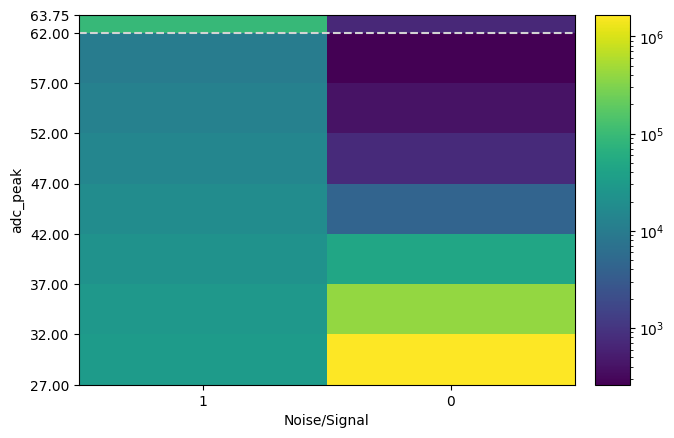

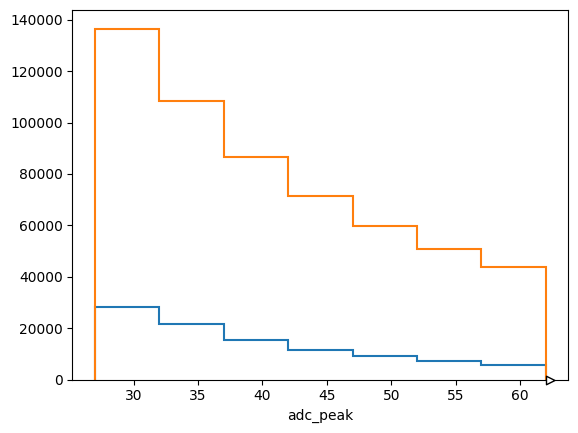

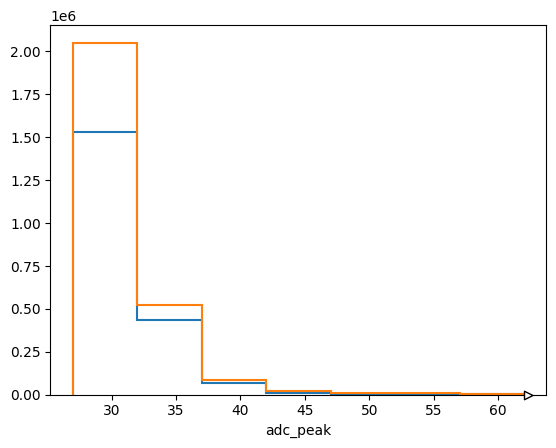

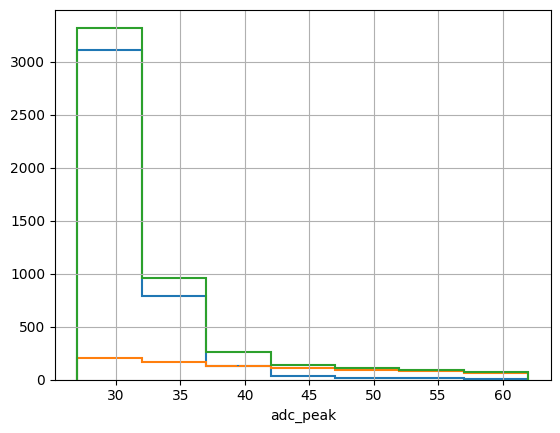

In [ ]:
h_spec = [rop_axis, adc_peak_axis]
h_spec = [rop_axis, bt_sig_axis]
h_spec = [rop_axis, bt_sig_axis, adc_peak_axis]


h = hist.Hist(*h_spec)

kwa = {
    a.name: _df[a.name]
    for a in h_spec
}
h.fill(**kwa)



# kwa={
#     'readout_plane_id': _df['readout_plane_id'],
#     'adc_peak': _df['adc_peak'],
# }
fig, ax = plt.subplots()

artists = hep.hist2dplot(h[2, :, :], flow='show', norm=LogNorm(), ax=ax)

display(h)

from tpvalidator.analysis.histograms import cumsum_hist

rop_id = 1
h_coll_sig = h[rop_id,1j, :]
h_coll_noi = h[rop_id,0j, :]
display(h_coll_sig)


fig, ax = plt.subplots()
print(h_coll_sig.values(flow=True))
hep.histplot(h_coll_sig, ax=ax)

h_coll_sig_cum = cumsum_hist(h_coll_sig, direction='right', flow=True)
hep.histplot(h_coll_sig_cum, ax=ax)

fig, ax = plt.subplots()
print(h_coll_noi.values(flow=True))
hep.histplot(h_coll_noi, ax=ax)

h_coll_noi_cum = cumsum_hist(h_coll_noi, direction='right', flow=True)
hep.histplot(h_coll_noi_cum, ax=ax)

sim_t = tpp.simulated_time()

num_crp = 28

h_coll_all_sum = h_coll_sig_cum+h_coll_noi_cum

h_rate_crp_col_noi = h_coll_noi_cum*sim_t/num_crp
h_rate_crp_col_sig = h_coll_sig_cum*sim_t/num_crp
h_rate_crt_col_all = h_coll_all_sum*sim_t/num_crp

fig, ax = plt.subplots()
hep.histplot(h_rate_crp_col_noi, ax=ax)
hep.histplot(h_rate_crp_col_sig, ax=ax)
hep.histplot(h_rate_crt_col_all, ax=ax)
ax.grid(True)



# print(h[2,:].values(flow=True))
# print(sum(h[2,:].values(flow=True)))

In [ ]:
from rich.table import Table

_t = Table('adc_peak cut', 'rate/CRP [Hz]', 'counts (all)', 'counts (sig)', 'counts (noise)')

for i, e in enumerate(h_rate_crt_col_all.axes[0].edges[:-1]):
    _bin_val = h_rate_crt_col_all[i]
    _bin_count_val = h_coll_all_sum[i]
    _bin_count_val_sig = h_coll_sig_cum[i]
    _bin_count_val_noi = h_coll_noi_cum[i]
    print(i, e, _bin_val.value, _bin_val.variance)
    _t.add_row(f">= {int(e):d}", f"{_bin_val.value:.2f}", f"{int(_bin_count_val.value)}", f"{int(_bin_count_val_sig.value)}",f"{int(_bin_count_val_noi.value)}")

print(_t)

0 27.0 3317.879375 5.036066908482142

1 32.0 955.6352678571428 1.450517817283163

2 37.0 263.91589285714286 0.4005866230867346

3 42.0 139.79008928571426 0.21218138552295918

4 46.99999999999999 106.05571428571429 0.16097742346938773

5 52.0 88.20723214285714 0.13388597735969385

6 57.0 74.76357142857141 0.11348042091836733

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ adc_peak cut ┃ rate/CRP [Hz] ┃ counts (all) ┃ counts (sig) ┃ counts (noise) ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ >= 27        │ 3317.88       │ 2185897      │ 136586       │ 2049311        │
│ >= 32        │ 955.64        │ 629595       │ 108255       │ 521340         │
│ >= 37        │ 263.92        │ 173874       │ 86565        │ 87309          │
│ >= 42        │ 139.79        │ 92097        │ 71301        │ 20796          │
│ >= 46        │ 106.06        │ 69872        │ 59721        │ 10151          │
│ >= 52        │ 88.21         │ 58113        │ 50734        │ 7379           │
│ >= 57        │ 74.76         │ 49256        │ 43617        │ 5639           │
└──────────────┴───────────────┴──────────────┴──────────────┴────────────────┘

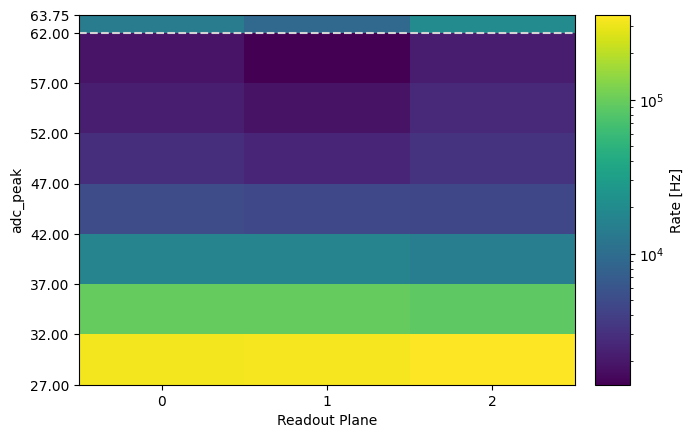

In [ ]:
sim_t = tpp.simulated_time()

h_rate_crp = h/sim_t/112

artists = hep.hist2dplot(h_rate_crp, flow='show', norm=LogNorm())
artists.cbar.set_label("Rate [Hz]")

In [ ]:
tpsel.sig_by_view[0]

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     0             1  99001       0        2     0      3    95922   
      1             1  99001       0        2     0      3    95923   
      3             1  99001       0        2     0      3    95944   
      9             1  99001       0        2     0      3    95949   
      15            1  99001       0        2     0      3    95954   
...               ...    ...     ...      ...   ...    ...      ...   
9     668022        5  99001       1        2     0      3      257   
      668023        5  99001       1        2     0      3      258   
      668027        5  99001       1        2     0      3      264   
      668028        5  99001       1        2     0      3      264   
      668029        5  99001       1        2     0      3      267   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     0                              2       50144                1  ...   
      1                              6       50016                3  ...   
      3                              6      162464                3  ...   
      9                              2      157408                0  ...   
      15                             4       36064                3  ...   
...                                ...         ...              ...  ...   
9     668022                         6      250336                2  ...   
      668023                         6      250336                2  ...   
      668027                         4       39872                2  ...   
      668028                         6      202432                3  ...   
      668029                         1      236480                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     0           198.401642    513.960205   1969.147583                  8   
      1           198.402817    513.966858   1969.153076                  8   
      3            35.387203    512.494141   2003.964478                  8   
      9           313.666901    540.348145   1963.247925                 10   
      15         -177.105255    545.124084   1962.454102                  8   
...                      ...           ...           ...                ...   
9     668022      128.925674   -526.858521    139.013382                  8   
      668023      128.925125   -526.856445    139.012863                  8   
      668027      321.325348   -515.180786    128.937729                 10   
      668028      324.570862   -513.353638    125.073624                 10   
      668029      261.730408   -523.645203    147.610962                 10   

                          bt_generator_name  event_uid  time_peak  \
entry subentry                                                      
0     0                        Ar39GenInLAr  216752193      50176   
      1                        Ar39GenInLAr  216752193      50112   
      3                        Ar39GenInLAr  216752193     162560   
      9         CavernwallGammasAtLAr1x8x14  216752193     157408   
      15                       Ar39GenInLAr  216752193      36160   
...                                     ...        ...        ...   
9     668022                   Ar39GenInLAr  216752297     250400   
      668023                   Ar39GenInLAr  216752297     250400   
      668027    CavernwallGammasAtLAr1x8x14  216752297      39936   
      668028    CavernwallGammasAtLAr1x8x14  216752297     202528   
      668029    CavernwallGammasAtLAr1x8x14  216752297     236480   

                sample_start  sample_peak  bt_is_signal  
entry subentry                                           
0     0                 1567         1568             1  
   

In [ ]:
tpp._df.bt_generator_name.unique()

<ArrowStringArray>
[                           'Ar39GenInLAr',
                                        '',
             'CavernwallGammasAtLAr1x8x14',
                            'Kr85GenInLAr',
                   'foamGammasAtLAr1x8x14',
                  'Th232ChainGenInCathode',
                     'U238ChainGenInAnode',
                            'Ar42GenInLAr',
                    'Th232ChainGenInAnode',
 'Rn222ChainFromBi210GenInUpperMesh1x8x14',
                           'K40GenInAnode',
                   'U238ChainGenInCathode',
                         'K40GenInCathode',
 'Rn222ChainFromBi214GenInUpperMesh1x8x14',
                 'Rn222ChainPb214GenInLAr',
                 'Rn222ChainBi214GenInLAr',
                 'Rn220ChainPb212GenInLAr',
 'Rn222ChainFromPb214GenInUpperMesh1x8x14',
                 'Rn222ChainPo218GenInLAr',
 'Rn220ChainFromPb212GenInUpperMesh1x8x14',
                 'Rn222ChainRn222GenInLAr',
         'K42From42ArGenInUpperMesh1x8x14',
             

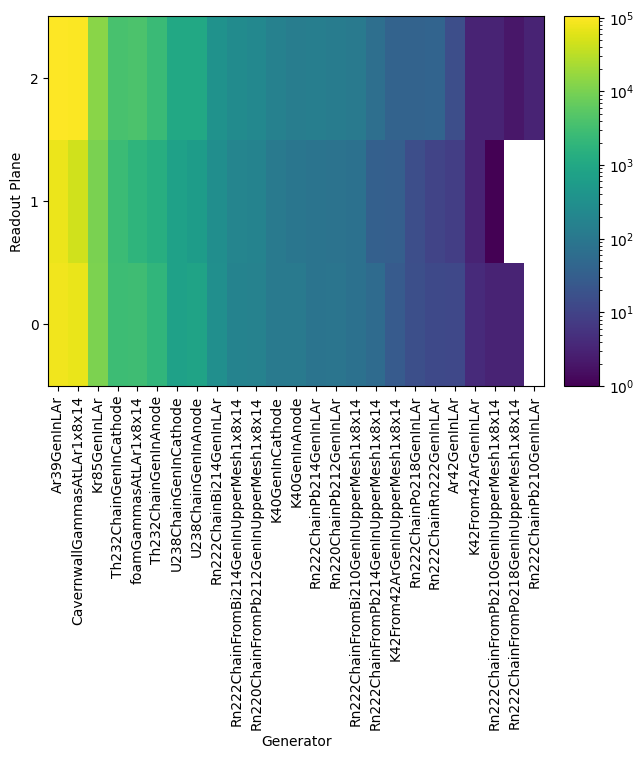

In [ ]:

from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
h = tpp.make_generator_counts_hist('bt_is_signal == 1')
norm = LogNorm(vmin=1, vmax=h.values().max())

hep.hist2dplot(h, ax=ax,  norm=norm)
ax.tick_params(axis='x', rotation=90)


In [ ]:
display(h[sum, :])

IndexError: Wrong number of indices for histogram

In [ ]:
fig = tpp.plot_generator_activity(cut='adc_peak>45', norm='rate')

AttributeError: 'TrgPrimitivesPlotter' object has no attribute 'plot_generator_activity'

In [ ]:
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==0"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==1"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==2"))

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 44010   │ 1035529.41 │
│ Ar39GenInLAr                            │ 36911   │ 868494.12  │
│ ElecNoise                               │ 11457   │ 269576.47  │
│ Kr85GenInLAr                            │ 5564    │ 130917.65  │
│ foamGammasAtLAr1x8x14                   │ 1817    │ 42752.94   │
│ Th232ChainGenInAnode                    │ 1395    │ 32823.53   │
│ Th232ChainGenInCathode                  │ 1278    │ 30070.59   │
│ U238ChainGenInAnode                     │ 582     │ 13694.12   │
│ U238ChainGenInCathode                   │ 307     │ 7223.53    │
│ Rn222ChainBi214GenInLAr                 │ 164     │ 3858.82    │
│ K40GenInAnode                           │ 97      │ 2282.35    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 95      │ 2235.29    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 94      │ 2211.76    │
│ K40GenInCathode                         │ 56      │ 1317.65    │
│ Rn220ChainPb212GenInLAr                 │ 56      │ 1317.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 30      │ 705.88     │
│ Rn222ChainPb214GenInLAr                 │ 29      │ 682.35     │
│ K42From42ArGenInUpperMesh1x8x14         │ 21      │ 494.12     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ K42From42ArGenInLAr                     │ 3       │ 70.59      │
│ Rn222ChainPo218GenInLAr                 │ 1       │ 23.53      │
└─────────────────────────────────────────┴─────────┴────────────┘

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz] ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 32375   │ 761764.71 │
│ Ar39GenInLAr                            │ 20838   │ 490305.88 │
│ ElecNoise                               │ 11196   │ 263435.29 │
│ Kr85GenInLAr                            │ 3631    │ 85435.29  │
│ foamGammasAtLAr1x8x14                   │ 1367    │ 32164.71  │
│ Th232ChainGenInCathode                  │ 1141    │ 26847.06  │
│ Th232ChainGenInAnode                    │ 1128    │ 26541.18  │
│ U238ChainGenInAnode                     │ 461     │ 10847.06  │
│ U238ChainGenInCathode                   │ 241     │ 5670.59   │
│ Rn222ChainBi214GenInLAr                 │ 134     │ 3152.94   │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 85      │ 2000.00   │
│ K40GenInAnode                           │ 83      │ 1952.94   │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 81      │ 1905.88   │
│ Rn220ChainPb212GenInLAr                 │ 46      │ 1082.35   │
│ K40GenInCathode                         │ 39      │ 917.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 25      │ 588.24    │
│ Rn222ChainPb214GenInLAr                 │ 20      │ 470.59    │
│ K42From42ArGenInUpperMesh1x8x14         │ 19      │ 447.06    │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82    │
│ Ar42GenInLAr                            │ 2       │ 47.06     │
│ K42From42ArGenInLAr                     │ 2       │ 47.06     │
│ Rn222ChainRn222GenInLAr                 │ 2       │ 47.06     │
└─────────────────────────────────────────┴─────────┴───────────┘

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 60735   │ 1429058.82 │
│ Ar39GenInLAr                            │ 55715   │ 1310941.18 │
│ Kr85GenInLAr                            │ 7752    │ 182400.00  │
│ foamGammasAtLAr1x8x14                   │ 2448    │ 57600.00   │
│ ElecNoise                               │ 2417    │ 56870.59   │
│ Th232ChainGenInCathode                  │ 1822    │ 42870.59   │
│ Th232ChainGenInAnode                    │ 1773    │ 41717.65   │
│ U238ChainGenInAnode                     │ 726     │ 17082.35   │
│ U238ChainGenInCathode                   │ 429     │ 10094.12   │
│ Rn222ChainBi214GenInLAr                 │ 203     │ 4776.47    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 131     │ 3082.35    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 120     │ 2823.53    │
│ K40GenInAnode                           │ 112     │ 2635.29    │
│ K40GenInCathode                         │ 83      │ 1952.94    │
│ Rn220ChainPb212GenInLAr                 │ 72      │ 1694.12    │
│ Rn222ChainPb214GenInLAr                 │ 59      │ 1388.24    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 49      │ 1152.94    │
│ K42From42ArGenInUpperMesh1x8x14         │ 30      │ 705.88     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 21      │ 494.12     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ Rn222ChainRn222GenInLAr                 │ 3       │ 70.59      │
│ K42From42ArGenInLAr                     │ 2       │ 47.06      │
│ Rn222ChainPo218GenInLAr                 │ 2       │ 47.06      │
└─────────────────────────────────────────┴─────────┴────────────┘

In [ ]:
coll_tps = ws.tps.query('readout_view == 2 & sample_start >100 & sample_start < 8100 & bt_is_signal == 1 ')
coll_tps.extra_info.update({'readout_window': 8000})


NameError: name 'ws' is not defined

In [ ]:
tps_by_gen = sorted([(n,df) for n,df in coll_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


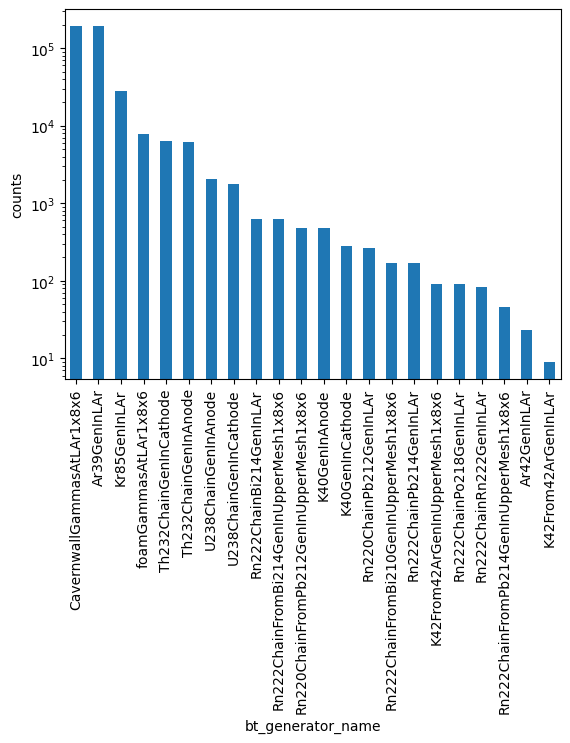

In [ ]:
counts = coll_tps.bt_generator_name.value_counts()
ax = counts.plot.bar()
ax.set_ylabel('counts')
ax.set_yscale('log')